# 01 Build CSV from Raw AWR Sample

- 分別掃描 AWR_steady/raw/mmWave 與 AWR_unsteady/raw/mmWave
- 逐筆讀取 .dat
- 解析 TLV packets
- 從 heatmap 抽出 heart waveform
- 回到 AWR_steady/、AWR_unsteady/ 底下，為每筆建立 data_x/
- 把波形存成 waveform.csv

In [2]:
import os
import re
import struct
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

ROOTS = {
    "AWR_steady": os.path.join("D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady", "raw", "mmWave"),
    "AWR_unsteady": os.path.join("D:/mmwave-heart-rate-monitoring-demo/data/AWR_unsteady", "raw", "mmWave"),
}

ASSUME_RECORD_SECONDS = 60.0

TLV_RANGE_PROFILE = 2
TLV_NOISE_PROFILE = 3
TLV_AZIMUTH_STATIC_HEATMAP = 4

MAGIC = b"\x02\x01\x04\x03\x06\x05\x08\x07"


def iter_dat_files(root_dir: str):
    for dpath, _, fnames in os.walk(root_dir):
        for fn in sorted(fnames):
            if fn.lower().endswith(".dat"):
                yield os.path.join(dpath, fn)


# demo：列出每個資料夾前幾筆 .dat
for label, mmwave_dir in ROOTS.items():
    print(f"\n[{label}] {mmwave_dir}")
    if os.path.isdir(mmwave_dir):
        files = list(iter_dat_files(mmwave_dir))
        print("Total .dat files:", len(files))
        for f in files[:3]:
            print(" -", f)
    else:
        print("Directory not found")


[AWR_steady] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave
Total .dat files: 50
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_0.dat
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_1.dat
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_10.dat

[AWR_unsteady] D:/mmwave-heart-rate-monitoring-demo/data/AWR_unsteady\raw\mmWave
Total .dat files: 80
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_unsteady\raw\mmWave\sample_0.dat
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_unsteady\raw\mmWave\sample_1.dat
 - D:/mmwave-heart-rate-monitoring-demo/data/AWR_unsteady\raw\mmWave\sample_10.dat


In [3]:
def read_packets(file_path: str):
    buf = open(file_path, "rb").read()
    packets = []

    i = 0
    n = len(buf)
    while True:
        j = buf.find(MAGIC, i)
        if j == -1 or j + 40 > n:
            break

        version, total_len, platform, frame_num, time_cpu, num_obj, num_tlvs, subframe = struct.unpack_from(
            "<8I", buf, j + 8
        )

        if total_len < 40 or j + total_len > n:
            i = j + 1
            continue

        pkt = buf[j:j + total_len]
        packets.append((pkt, {
            "version": version,
            "total_len": total_len,
            "platform": platform,
            "frame_num": frame_num,
            "time_cpu": time_cpu,
            "num_obj": num_obj,
            "num_tlvs": num_tlvs,
            "subframe": subframe,
        }))
        i = j + total_len

    if len(packets) == 0:
        raise RuntimeError("No valid packets found. Check file format.")
    return packets

if __name__ == "__main__":
    # demo：拿第一筆 steady 檔案測試
    steady_files = list(iter_dat_files(ROOTS["AWR_steady"]))
    sample_dat = steady_files[0]

    packets = read_packets(sample_dat)
    print("Sample file:", sample_dat)
    print("Total packets:", len(packets))
    print("First packet header:")
    print(packets[0][1])

Sample file: D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_0.dat
Total packets: 300
First packet header:
{'version': 67567876, 'total_len': 3520, 'platform': 10564, 'frame_num': 1823, 'time_cpu': 0, 'num_obj': 1, 'num_tlvs': 7, 'subframe': 0}


Range profile shape : (300, 64)
Noise profile shape : (300, 64)
Heatmap shape       : (300, 64, 12)
Times shape         : (300,)


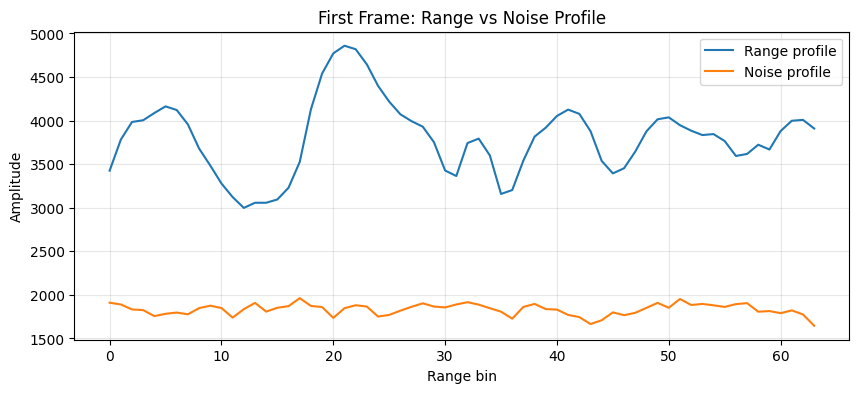

In [4]:
def parse_tlvs(pkt: bytes, num_tlvs: int):
    pos = 40
    tlv = {}
    for _ in range(num_tlvs):
        if pos + 8 > len(pkt):
            break
        tlv_type, tlv_len = struct.unpack_from("<II", pkt, pos)
        start = pos + 8
        end = min(start + tlv_len, len(pkt))
        payload = pkt[start:end]
        tlv[tlv_type] = payload
        pos = end
    return tlv


def extract_series(packets):
    rps, nps, hms, times = [], [], [], []
    num_range_bins = None
    num_ant = None

    for pkt, hdr in packets:
        tlv = parse_tlvs(pkt, hdr["num_tlvs"])

        if TLV_RANGE_PROFILE not in tlv or TLV_AZIMUTH_STATIC_HEATMAP not in tlv:
            continue

        rp = np.frombuffer(tlv[TLV_RANGE_PROFILE], dtype=np.uint16)
        if num_range_bins is None:
            num_range_bins = rp.size
        rp = rp[:num_range_bins].astype(np.float32)

        if TLV_NOISE_PROFILE in tlv:
            npf = np.frombuffer(tlv[TLV_NOISE_PROFILE], dtype=np.uint16)[:num_range_bins].astype(np.float32)
        else:
            npf = np.zeros_like(rp)

        hm_bytes = tlv[TLV_AZIMUTH_STATIC_HEATMAP]
        total_complex = len(hm_bytes) // 4
        if total_complex % num_range_bins != 0:
            continue

        if num_ant is None:
            num_ant = total_complex // num_range_bins

        hm_i16 = np.frombuffer(hm_bytes, dtype=np.int16).reshape(-1, 2)
        c = hm_i16[:, 0].astype(np.float32) + 1j * hm_i16[:, 1].astype(np.float32)
        c = c.reshape(num_range_bins, num_ant).astype(np.complex64)

        rps.append(rp)
        nps.append(npf)
        hms.append(c)
        times.append(hdr["time_cpu"])

    if len(rps) < 10:
        raise RuntimeError("Too few usable frames parsed (need TLV2 & TLV4).")

    rp = np.stack(rps, axis=0)
    npf = np.stack(nps, axis=0)
    hm = np.stack(hms, axis=0)
    times = np.array(times, dtype=np.uint32)

    return rp, npf, hm, times

if __name__ == "__main__":
    rp, npf, hm, times = extract_series(packets)

    print("Range profile shape :", rp.shape)
    print("Noise profile shape :", npf.shape)
    print("Heatmap shape       :", hm.shape)
    print("Times shape         :", times.shape)

    # demo：看第一幀 range / noise
    plt.figure(figsize=(10, 4))
    plt.plot(rp[0], label="Range profile")
    plt.plot(npf[0], label="Noise profile")
    plt.title("First Frame: Range vs Noise Profile")
    plt.xlabel("Range bin")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Estimated fs       : 5.0000 Hz
Duration           : 60.00 s
Selected range bin : 22
Bandpass           : 0.80-2.49 Hz


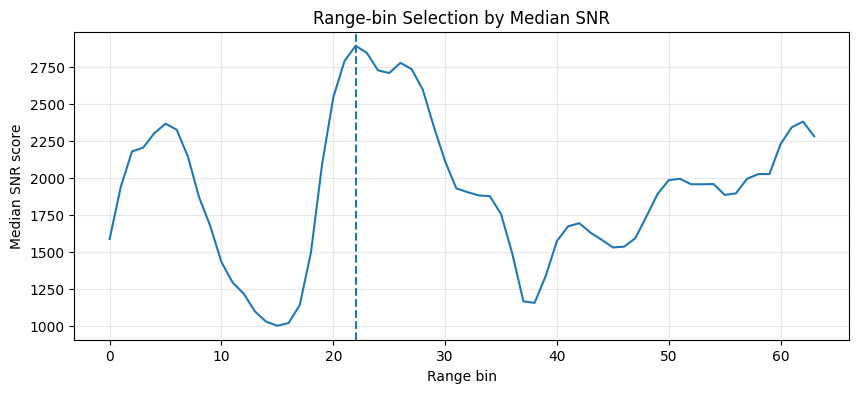

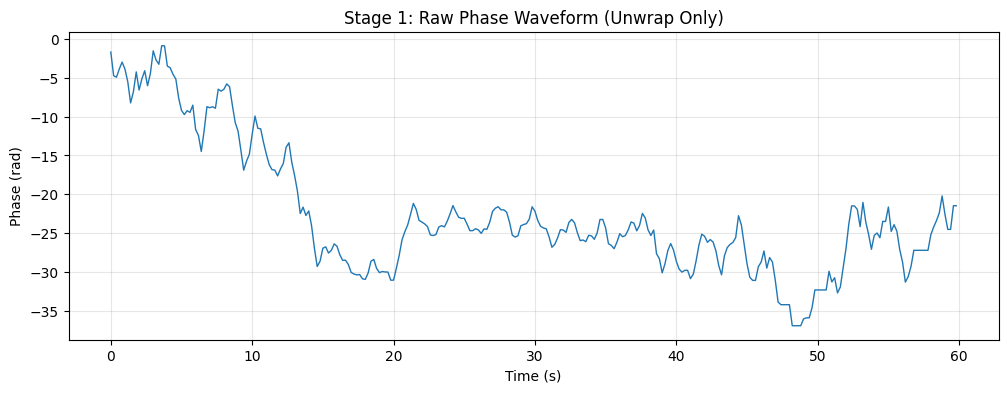

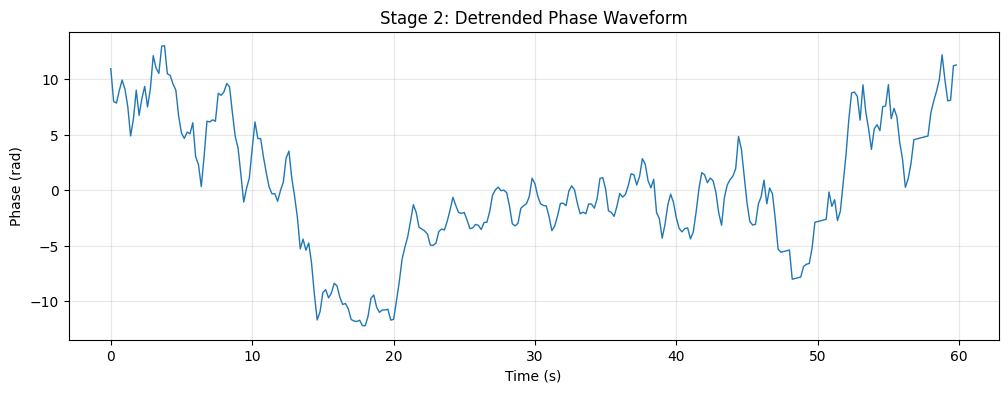

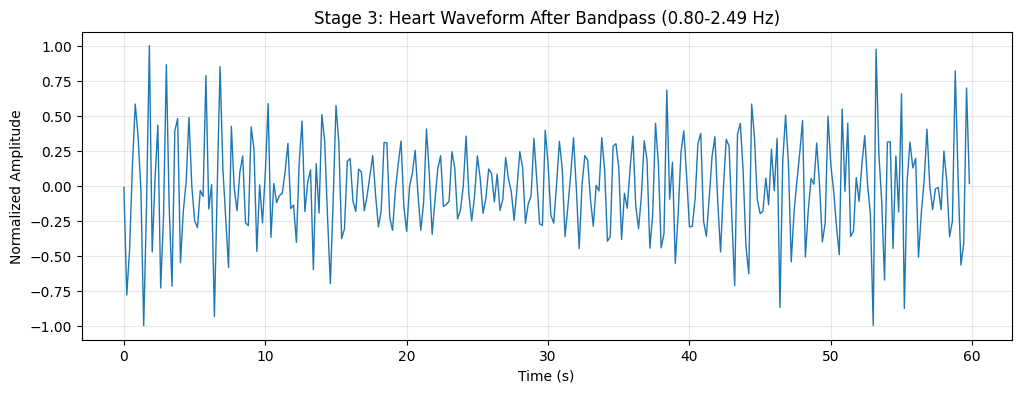

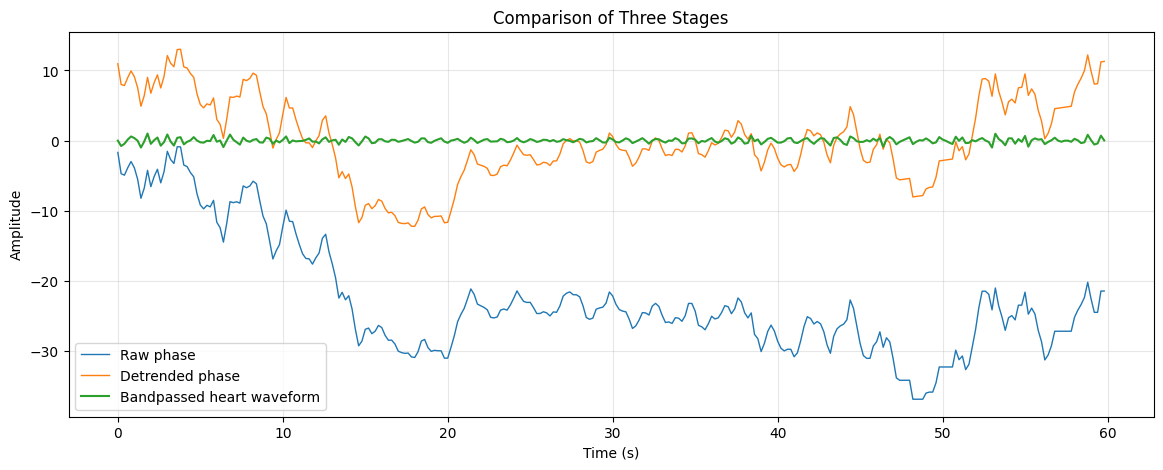

In [5]:
def estimate_fs(times_u32: np.ndarray, n_frames: int):
    if n_frames < 2:
        return None, None

    if np.any(times_u32 != times_u32[0]):
        dt = np.diff(times_u32.astype(np.float64))
        dt = dt[dt > 0]
        if len(dt) > 0:
            med = float(np.median(dt))
            if 5 <= med <= 5000:
                fs = 1000.0 / med
                duration = n_frames / fs
                return fs, duration

    fs = n_frames / float(ASSUME_RECORD_SECONDS)
    duration = float(ASSUME_RECORD_SECONDS)
    return fs, duration


def select_range_bin_by_snr(rp, npf, ignore_bins=2):
    snr = rp - npf
    score = np.median(snr, axis=0)
    idx = int(np.argmax(score[ignore_bins:]) + ignore_bins)
    return idx, score


def phase_raw_from_heatmap(hm, bin_idx):
    c = hm[:, bin_idx, :].sum(axis=1)
    phase = np.angle(c)
    phase = np.unwrap(phase)

    return phase


def phase_detrended_from_heatmap(hm, bin_idx):
    # raw phase
    phase = phase_raw_from_heatmap(hm, bin_idx)

    # detrend
    phase_detrended = signal.detrend(phase, type="linear")

    return phase_detrended


def heart_waveform_from_heatmap(hm, fs, bin_idx, fmin=0.8, fmax=3.0):
    # raw phase
    phase = phase_raw_from_heatmap(hm, bin_idx)

    # detrend
    phase = signal.detrend(phase, type="linear")

    nyq = fs / 2.0
    if nyq <= fmin + 0.05:
        raise RuntimeError(f"fs too low ({fs:.3f} Hz). Nyquist={nyq:.3f} < heart band.")

    # bandpass
    fmax_eff = min(fmax, nyq - 0.01)
    b, a = signal.butter(4, [fmin / nyq, fmax_eff / nyq], btype="bandpass") # HR：48~180 bpm
    heart = signal.filtfilt(b, a, phase)

    # normalize to [-1, 1]
    heart_min = float(np.min(heart))
    heart_max = float(np.max(heart))
    if heart_max - heart_min > 1e-6:
        heart = 2 * (heart - heart_min) / (heart_max - heart_min) - 1
    else:
        heart = np.zeros_like(heart)

    return heart, fmin, fmax_eff


if __name__ == "__main__":
    n_frames = rp.shape[0]
    fs, duration = estimate_fs(times, n_frames)
    bin_idx, score = select_range_bin_by_snr(rp, npf, ignore_bins=2)

    # 三階段
    phase_raw = phase_raw_from_heatmap(hm, bin_idx)
    phase_detrended = phase_detrended_from_heatmap(hm, bin_idx)
    heart_bandpassed, fmin, fmax_eff = heart_waveform_from_heatmap(hm, fs, bin_idx)

    # 時間軸
    t_sec = np.arange(len(phase_raw), dtype=np.float64) / float(fs)
    t_frame = np.arange(len(phase_raw))

    print(f"Estimated fs       : {fs:.4f} Hz")
    print(f"Duration           : {duration:.2f} s")
    print(f"Selected range bin : {bin_idx}")
    print(f"Bandpass           : {fmin:.2f}-{fmax_eff:.2f} Hz")

    # demo 1：SNR score
    plt.figure(figsize=(10, 4))
    plt.plot(score)
    plt.axvline(bin_idx, linestyle="--")
    plt.title("Range-bin Selection by Median SNR")
    plt.xlabel("Range bin")
    plt.ylabel("Median SNR score")
    plt.grid(True, alpha=0.3)
    plt.show()

    # demo 2：三階段分開畫
    plt.figure(figsize=(12, 4))
    plt.plot(t_sec, phase_raw, linewidth=1)
    plt.title("Stage 1: Raw Phase Waveform (Unwrap Only)")
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(t_sec, phase_detrended, linewidth=1)
    plt.title("Stage 2: Detrended Phase Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(t_sec, heart_bandpassed, linewidth=1)
    plt.title(f"Stage 3: Heart Waveform After Bandpass ({fmin:.2f}-{fmax_eff:.2f} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True, alpha=0.3)
    plt.show()

    # demo 3：三階段畫在同一張（方便比較）
    plt.figure(figsize=(14, 5))
    plt.plot(t_sec, phase_raw, linewidth=1, label="Raw phase")
    plt.plot(t_sec, phase_detrended, linewidth=1, label="Detrended phase") # 把訊號中「慢慢往上或往下漂移的基線（baseline drift）」拿掉，只留下真正的振動訊號。
    plt.plot(t_sec, heart_bandpassed, linewidth=1.5, label="Bandpassed heart waveform")
    plt.title("Comparison of Three Stages")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def next_data_index(out_root: str) -> int:
    os.makedirs(out_root, exist_ok=True)
    pat = re.compile(r"^data_(\d+)$", re.IGNORECASE)
    mx = 0
    for name in os.listdir(out_root):
        full = os.path.join(out_root, name)
        if os.path.isdir(full):
            m = pat.match(name)
            if m:
                mx = max(mx, int(m.group(1)))
    return mx + 1


def save_csv_with_meta(out_csv: str, t: np.ndarray, heart: np.ndarray, meta: dict):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    with open(out_csv, "w", encoding="utf-8") as f:
        for k, v in meta.items():
            f.write(f"# {k}={v}\n")
        f.write("time,LSB\n")
        for ti, xi in zip(t, heart):
            f.write(f"{ti:.12f},{xi:.9f}\n")


def process_one_file(in_path: str, out_csv: str):
    packets = read_packets(in_path)
    rp, npf, hm, times = extract_series(packets)

    n_frames = rp.shape[0]
    fs, duration = estimate_fs(times, n_frames)
    bin_idx, score = select_range_bin_by_snr(rp, npf, ignore_bins=2)
    heart, fmin, fmax_eff = heart_waveform_from_heatmap(hm, fs, bin_idx)
    t = np.arange(len(heart), dtype=np.float64) / float(fs)

    meta = {
        "source_file": os.path.basename(in_path),
        "source_path": in_path,
        "frames_used": n_frames,
        "fs": fs,
        "duration_s": duration,
        "selected_range_bin": bin_idx,
        "median_snr_score": float(score[bin_idx]),
        "bandpass_hz": f"{fmin:.2f}-{fmax_eff:.2f}",
    }

    save_csv_with_meta(out_csv, t, heart, meta)
    return meta
if __name__ == "__main__":
    for out_root, mmwave_dir in ROOTS.items():
        out_root = "D:/mmwave-heart-rate-monitoring-demo/data/" + out_root
        print(f"\n[INFO] Processing: {mmwave_dir}")

        if not os.path.isdir(mmwave_dir):
            print(f"[WARN] Not found: {mmwave_dir}")
            continue

        dat_files = list(iter_dat_files(mmwave_dir))
        if not dat_files:
            print(f"[WARN] No .dat files found in {mmwave_dir}")
            continue

        idx = next_data_index(out_root)

        for in_path in dat_files:
            sample_name = os.path.splitext(os.path.basename(in_path))[0]
            sample_dir = os.path.join(out_root, sample_name)
            out_csv = os.path.join(sample_dir, "waveform.csv")

            try:
                process_one_file(in_path, out_csv)
                print(f"[OK] {in_path} -> {out_csv}")
                idx += 1
            except Exception as e:
                print(f"[FAIL] {os.path.basename(in_path)} | {type(e).__name__}: {e}")

    print("\nDone.")


[INFO] Processing: D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave
[OK] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_0.dat -> D:/mmwave-heart-rate-monitoring-demo/data/mmwave-heart-rate-dataset/AWR_steady\sample_0\mmWave_waveform.csv
[OK] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_1.dat -> D:/mmwave-heart-rate-monitoring-demo/data/mmwave-heart-rate-dataset/AWR_steady\sample_1\mmWave_waveform.csv
[OK] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_10.dat -> D:/mmwave-heart-rate-monitoring-demo/data/mmwave-heart-rate-dataset/AWR_steady\sample_10\mmWave_waveform.csv
[OK] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_11.dat -> D:/mmwave-heart-rate-monitoring-demo/data/mmwave-heart-rate-dataset/AWR_steady\sample_11\mmWave_waveform.csv
[OK] D:/mmwave-heart-rate-monitoring-demo/data/AWR_steady\raw\mmWave\sample_12.dat -> D:/mmwave-heart-rate-monitoring-demo/data/mmwave-heart